# Adult Census Income — 시각화 (Seaborn)

`src/visualize.py` 의 함수들로 차트를 그리고, 각 차트 아래에 관찰·해석을 정리한다.
데이터는 `notebooks/01_eda.ipynb` 로 정제된 `data/processed/adult_clean.parquet` (또는 `clean_pandas(load_pandas())`) 를 사용한다.

In [1]:
import sys

sys.path.insert(0, "..")
from src.data_loader import clean_pandas, load_pandas
from src.visualize import (
    plot_age_by_income,
    plot_correlation_heatmap,
    plot_hours_by_income,
)

pdf = clean_pandas(load_pandas())

[clean_pandas] 중복행 24건 제거
[clean_pandas] 결측치 포함 행 2398건 제거


## 나이 분포 (소득별)

[plot_age_by_income] 저장됨: /Users/skala/git/SKALA-Capstone2/output/chart2_age_by_income.png


<Axes: title={'center': '나이 분포 (소득별) (Age Distribution by Income)'}, xlabel='나이 (Age)', ylabel='밀도 (Density)'>

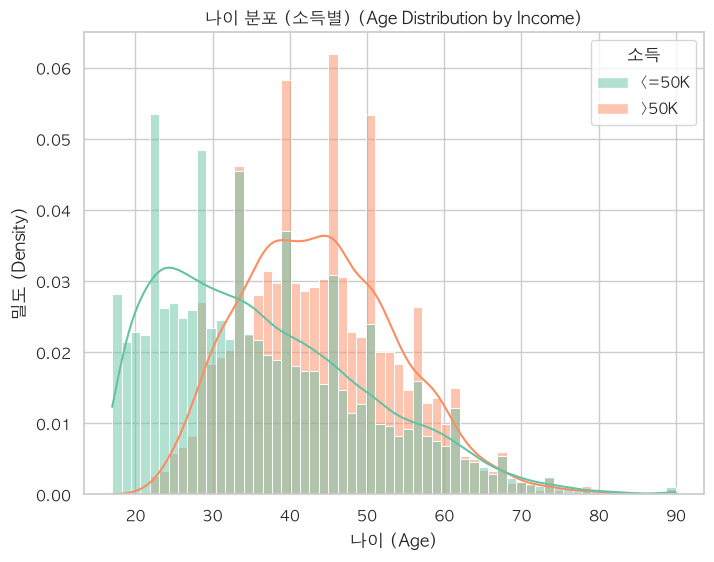

In [2]:
plot_age_by_income(pdf)

**관찰:** 저소득층(`<=50K`) 평균 나이 36.6세(중앙값 34, std 13.5)로 넓게 퍼져 있고, 고소득층(`>50K`) 평균 43.96세(중앙값 43, std 10.3)로 분포가 오른쪽(고령)으로 이동해 있다.

**해석:** 소득이 경력·연차와 함께 쌓이는 경향을 반영한다. 20대는 아직 경력 초반이라 `<=50K`에 몰리고 30~50대에서 고소득 비중이 커진다. 다만 고소득층도 std가 10을 넘어 특정 나이대에만 집중되진 않으므로, 나이 하나만으로 소득을 완전히 설명하긴 어렵다.

## 수치형 변수 간 상관관계

[plot_correlation_heatmap] 저장됨: /Users/skala/git/SKALA-Capstone2/output/chart_correlation_heatmap.png


<Axes: title={'center': '수치형 변수 간 상관관계 (Correlation Heatmap)'}>

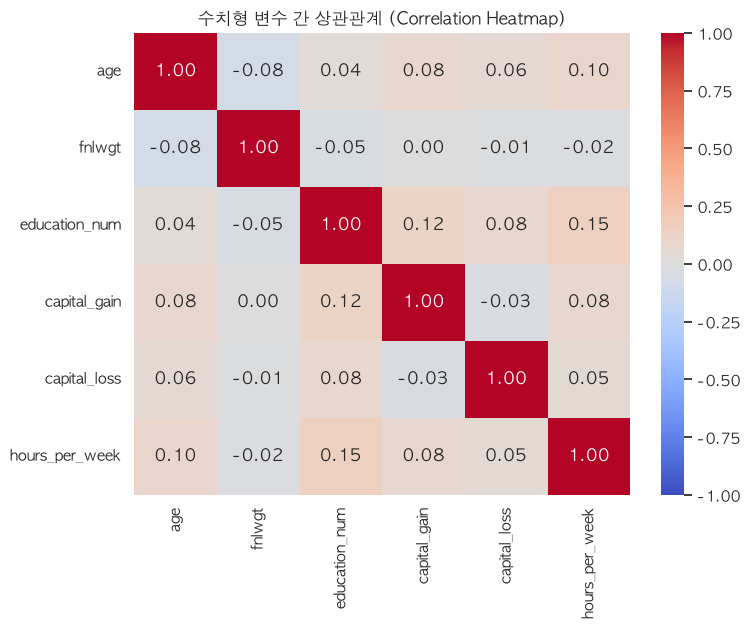

In [3]:
plot_correlation_heatmap(pdf)

**관찰:** 수치형 변수들끼리는 전반적으로 상관계수가 낮다(모두 |r| ≤ 0.15). 그중 `education_num`↔`hours_per_week`(0.15), `age`↔`hours_per_week`(0.10), `education_num`↔`capital_gain`(0.12)이 상대적으로 높고, `fnlwgt`는 다른 모든 변수와 거의 무상관(|r| ≤ 0.08)이다.

**해석:** 수치형 피처 간 다중공선성이 크지 않아 ML 모델에 함께 넣어도 문제가 적다. `fnlwgt`(인구총조사 가중치)는 소득 관련 변수들과 관계가 없어 예측 피처라기보다 표본 가중치 성격에 가깝다. `income`은 범주형이라 이 히트맵엔 안 잡히므로, 소득과의 실제 관계는 t-test·boxplot 등으로 별도 확인이 필요하다.

## 근무시간 vs 소득

[plot_hours_by_income] 저장됨: /Users/skala/git/SKALA-Capstone2/output/chart4_hours_by_income.png


<Axes: title={'center': '근무시간별 소득 분포 (Hours per Week by Income)'}, xlabel='소득 구간 (Income)', ylabel='주당 근무시간 (Hours per Week)'>

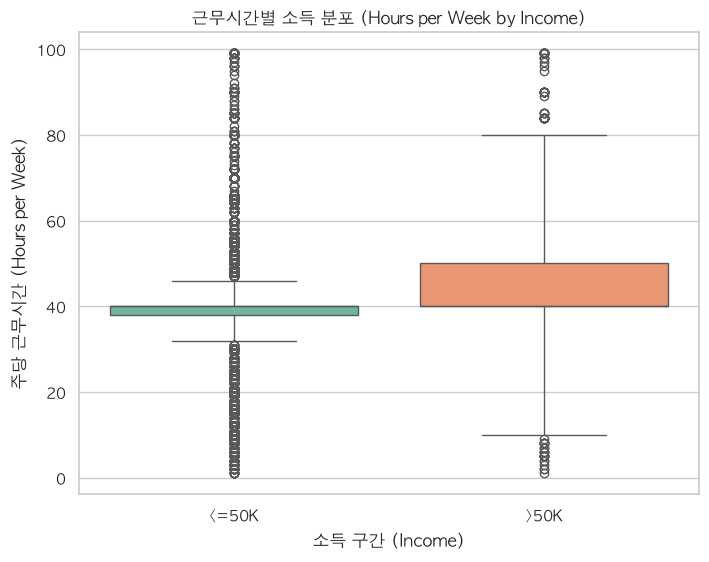

In [4]:
plot_hours_by_income(pdf)

**관찰:** 저소득층 평균 근무시간 39.35시간(중앙값 40)인 반면, 고소득층은 평균 45.71시간이고 75%ile이 50시간으로 더 오래 일하는 쪽에 치우쳐 있다.

**해석:** 고소득층이 저소득층보다 주당 평균 6시간 더 일하는 경향이 있지만, 위 상관관계 히트맵에서 `hours_per_week`↔`age` 상관이 0.10 수준으로 약했던 것과 마찬가지로 근무시간과 소득의 선형 관계 자체는 강하지 않다. 즉 오래 일한다고 곧 고소득은 아니며, 고소득층 내에서 근무시간이 더 긴 쪽으로 쏠리는 정도로 해석하는 게 맞다.